In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [ ]:
data = pd.Series([112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,
                  115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140])

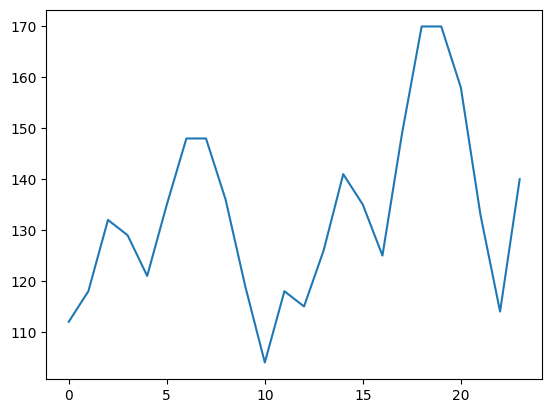

In [ ]:
plt.plot(data)
plt.show()

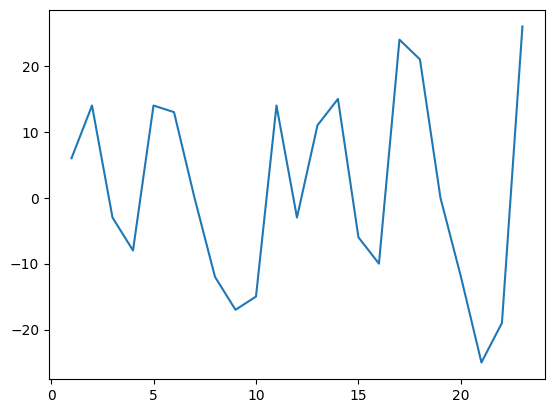

In [ ]:
diff_data = data.diff().dropna()
plt.plot(diff_data)
plt.show()

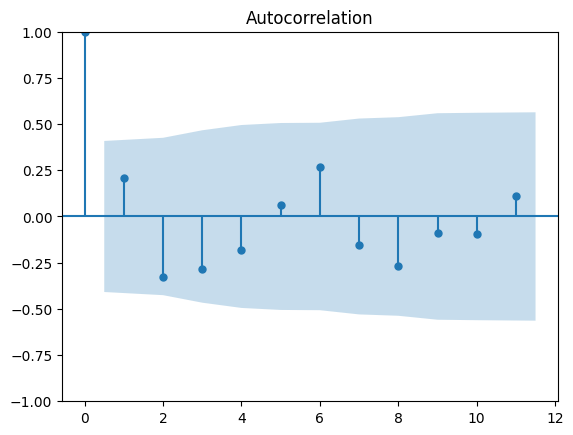

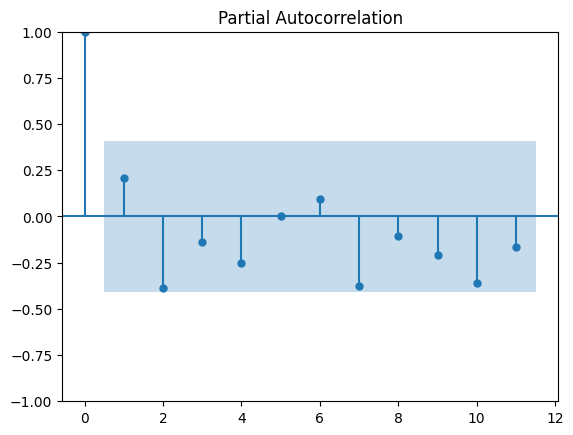

In [ ]:
plot_acf(diff_data)
plot_pacf(diff_data)
plt.show()

In [ ]:
model = ARIMA(data,order = (1,1,1))
model_fit = model.fit()

In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   24
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -92.270
Date:                Mon, 07 Oct 2024   AIC                            190.540
Time:                        12:07:53   BIC                            193.947
Sample:                             0   HQIC                           191.397
                                 - 24                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1429      0.676     -0.211      0.833      -1.468       1.182
ma.L1          0.6126      0.533      1.149      0.251      -0.433       1.658
sigma2       176.3081     68.800      2.563      0.0

In [ ]:
forecast = model_fit.forecast(steps = 5)
print(forecast)

24    154.395610
25    152.338815
26    152.632683
27    152.590696
28    152.596695
Name: predicted_mean, dtype: float64


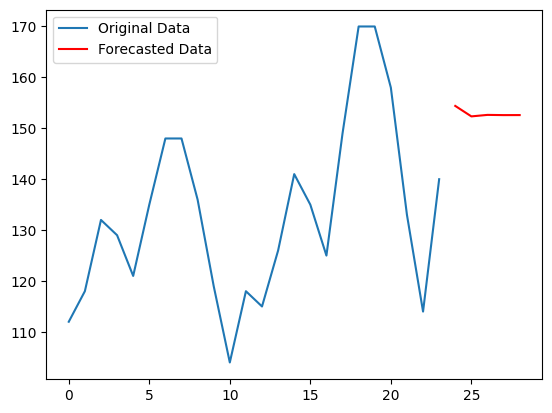

In [ ]:
plt.plot(data, label="Original Data")
plt.plot(range(len(data), len(data) + 5), forecast, label="Forecasted Data", color='red')
plt.legend()
plt.show()

In [ ]:
from pmdarima import auto_arima

auto_model = auto_arima(data,start_p = 1,start_q = 1,max_p = 3,max_q = 3,seasonal = False,d = 1,trace = True,error_action = 'ignore',suppress_warning = True)

print(auto_model.summary())

forecast_auto = auto_model.predict(n_periods = 5)
print(forecast_auto)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=192.343, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=192.130, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=193.013, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=190.555, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=190.293, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.803 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   24
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 -94.146
Date:                Mon, 07 Oct 2024   AIC                            190.293
Time:                        12:22:58   BIC                            191.428
Sample:                             0   HQIC                           190.578
                                 - 24                                         
Co

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.9 MB/s eta 0:00:00


In [ ]:
from prophet import Prophet

In [ ]:
data = {'ds': pd.date_range(start='2022-01-01', periods=100, freq='D'),
        'y': [x + (x*0.1) for x in range(100)]}

df = pd.DataFrame(data)

In [ ]:
model = Prophet()
model.fit(df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvnt19cm8/ygmdhjs1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvnt19cm8/3dtqzrsa.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28039', 'data', 'file=/tmp/tmpvnt19cm8/ygmdhjs1.json', 'init=/tmp/tmpvnt19cm8/3dtqzrsa.json', 'output', 'file=/tmp/tmpvnt19cm8/prophet_model4cj60had/prophet_model-20241007131345.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:13:45 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:13:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods = 30)

forecast = model.predict(future)

print(forecast)

            ds       trend  ...  multiplicative_terms_upper        yhat
0   2022-01-01    0.000327  ...                         0.0    0.000285
1   2022-01-02    1.100091  ...                         0.0    1.100077
2   2022-01-03    2.199854  ...                         0.0    2.199871
3   2022-01-04    3.299618  ...                         0.0    3.299656
4   2022-01-05    4.399822  ...                         0.0    4.399845
..         ...         ...  ...                         ...         ...
125 2022-05-06  137.500023  ...                         0.0  137.499999
126 2022-05-07  138.600024  ...                         0.0  138.599982
127 2022-05-08  139.700026  ...                         0.0  139.700012
128 2022-05-09  140.800028  ...                         0.0  140.800044
129 2022-05-10  141.900029  ...                         0.0  141.900068

[130 rows x 16 columns]


/usr/local/lib/python3.10/dist-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


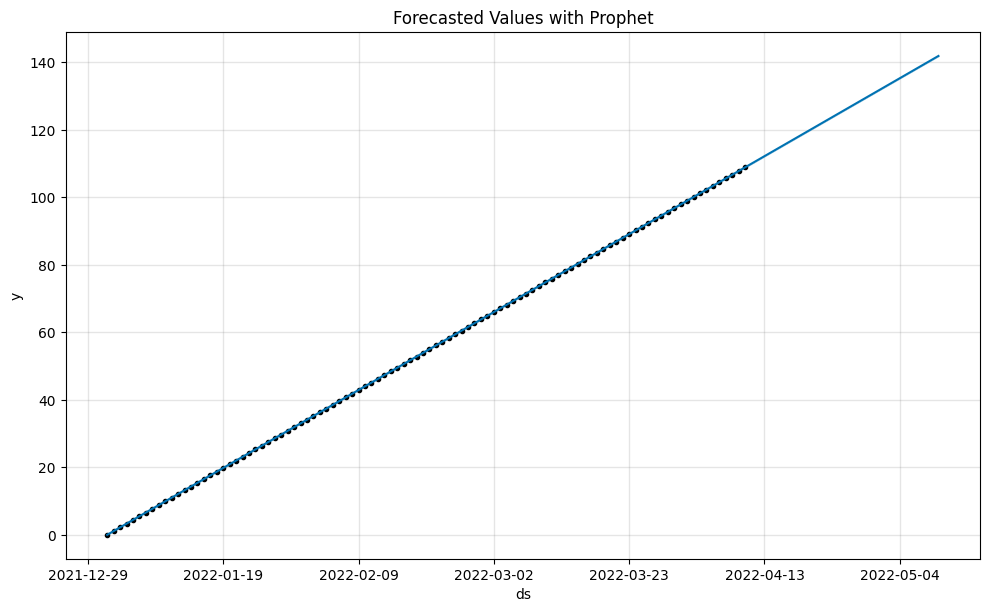

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()


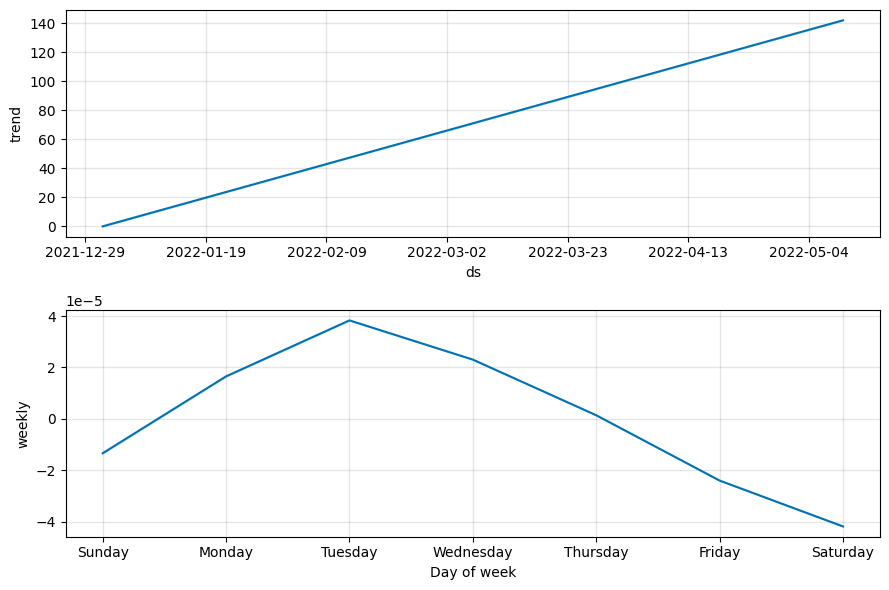

In [ ]:
model.plot(forecast)
plt.title('Forecasted Values with Prophet')
plt.show()


model.plot_components(forecast)
plt.show()

In [ ]:
#Handling Custom Seasonality and Holidays

In [ ]:
model = Prophet()

model.add_seasonality(name = 'monthly',period = 30.5,fourier_order = 5)

model.fit(df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvnt19cm8/kdjgikf1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvnt19cm8/c9rswl_k.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19442', 'data', 'file=/tmp/tmpvnt19cm8/kdjgikf1.json', 'init=/tmp/tmpvnt19cm8/c9rswl_k.json', 'output', 'file=/tmp/tmpvnt19cm8/prophet_modelt16h9a0p/prophet_model-20241007132225.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:22:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:22:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
holidays = pd.DataFrame({
    'holiday': 'custom_event',
    'ds': pd.to_datetime(['2022-03-01', '2022-09-01']),
    'lower_window': 0,
    'upper_window': 1,
})


model = Prophet(holidays = holidays)

model.fit(df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvnt19cm8/sqmcafqb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvnt19cm8/qtkhe8l7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12583', 'data', 'file=/tmp/tmpvnt19cm8/sqmcafqb.json', 'init=/tmp/tmpvnt19cm8/qtkhe8l7.json', 'output', 'file=/tmp/tmpvnt19cm8/prophet_modelwzt541lc/prophet_model-20241007132411.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:24:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:24:11 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
